In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

In [10]:
def initial_condition(x):
    u = np.zeros_like(x)
    for i in range(len(x)):
        if x[i] <= 0.5:
            u[i] = 2 * x[i]
        else:
            u[i] = 2 - 2 * x[i]
    return u

In [11]:
dx = 0.05
x_max = 1.0
t_max = 0.06
x_b = np.arange(0, x_max + dx / 2, dx)
Nx = len(x_b)

In [12]:
dt_c = 0.005
t_c = np.arange(0, t_max + dt_c / 2, dt_c)
Nt_c = len(t_c)

u_c = np.zeros((Nt_c, Nx))
u_c[0, :] = initial_condition(x_b)
alpha_c = dt_c / (dx**2)

In [13]:
A = np.zeros((Nx - 2, Nx - 2))
for i in range(Nx - 2):
    A[i, i] = 1 + 2 * alpha_c
    if i > 0:
        A[i, i - 1] = -alpha_c
    if i < Nx - 3:
        A[i, i + 1] = -alpha_c

In [14]:
# (A * u_next = u_prev)
for k in range(0, Nt_c - 1):
    b = u_c[k, 1:-1].copy()
    u_interior = la.solve(A, b)
    u_c[k + 1, 1:-1] = u_interior

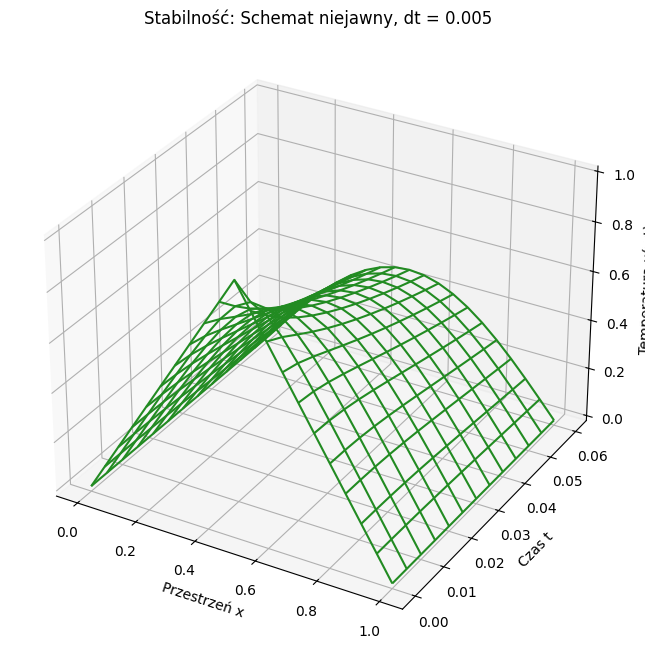

In [ ]:
fig2 = plt.figure(figsize=(10, 7))
ax2 = fig2.add_subplot(111, projection="3d")
X_c, T_c = np.meshgrid(x_b, t_c)
ax2.plot_wireframe(X_c, T_c, u_c, color="forestgreen")
ax2.set_xlabel("Przestrzeń x")
ax2.set_ylabel("Czas t")
ax2.set_zlabel("Temperatura u(x,t)")
ax2.set_title("Stabilność: Schemat niejawny, dt = 0.005")
plt.show()